# Building a Multi-Class Classification Model

- input shape = 28 x 28 (the shape of one image)
- output shape = 10 (one per class of clothing)
- loss function = tf.keras.losses.CategoricalCrossentropy()
- output layer activation = Softmax (not sigmoid)

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

In [4]:
tf.__version__

'2.19.1'

In [5]:
# data has already been sorted in training and testing datasets
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [9]:
# check the data
train_data[0], train_labels[0]

(array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
           0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
           1,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
           0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
           0,   3],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
           0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
          10

In [10]:
# check the shape
train_data[0].shape, train_labels[0].shape

((28, 28), ())

In [12]:
import matplotlib.pyplot as plt

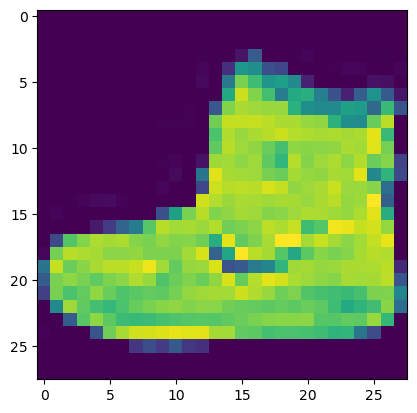

In [14]:
# plot a single data
plt.imshow(train_data[0])

In [15]:
# check the label
train_labels[0]

9

In [18]:
# create a index labels
class_names = ["T-shirts/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

In [20]:
len(class_names), class_names[train_labels[0]]

(10, 'Ankle Boot')

In [53]:
# check the min and max values of the training data
train_data.min(), train_data.max()

(0, 255)

In [59]:
# normalized the data between 0 and 1 values
data_max_value = train_data.max()
train_data_norm = train_data / data_max_value # 255.0
test_data_norm = test_data / data_max_value # 255.0

# check the values of normalized data
train_data_norm.min(), test_data_norm.max()

(0.0, 1.0)

In [74]:
tf.random.set_seed(42)

# create the model
total_classes = len(class_names)
model = tf.keras.models.Sequential([
    # Flatten the 28x28 image into a 1D array
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    
    # First hidden layer with 128 neurons
    tf.keras.layers.Dense(128, activation="relu"),

    # Second hidden layer with 64 neurons
    tf.keras.layers.Dense(64, activation="relu"),

    # Output layer with 10 neurons (one per class)
    tf.keras.layers.Dense(total_classes, activation=tf.keras.activations.softmax)
])

# compile the model
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(),
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
             metrics=["accuracy"])

# learning rate callback
enabled_learning_rate_callback = False
if enabled_learning_rate_callback: 
    lrt_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-3 * 10 ** (epoch/20))

epoch = 25
if enabled_learning_rate_callback:
    # fit the model
    history = model.fit(train_data_norm,
                        train_labels,
                        epochs=epoch,
                        validation_data=(test_data_norm, test_labels),
                        callbacks=lrt_callback)
else:
    # fit the model
    history = model.fit(train_data_norm,
                        train_labels,
                        epochs=epoch,
                        validation_data=(test_data_norm, test_labels))

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7772 - loss: 0.6478 - val_accuracy: 0.8445 - val_loss: 0.4231
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8606 - loss: 0.3839 - val_accuracy: 0.8588 - val_loss: 0.3849
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8729 - loss: 0.3426 - val_accuracy: 0.8632 - val_loss: 0.3700
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8816 - loss: 0.3161 - val_accuracy: 0.8648 - val_loss: 0.3618
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8882 - loss: 0.2968 - val_accuracy: 0.8689 - val_loss: 0.3607
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8937 - loss: 0.2797 - val_accuracy: 0.8699 - val_loss: 0.3554
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8981 - loss: 0.2661 - val_accuracy: 0.8766 - val_loss: 0.3490
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9033 - loss: 0.2548 - 

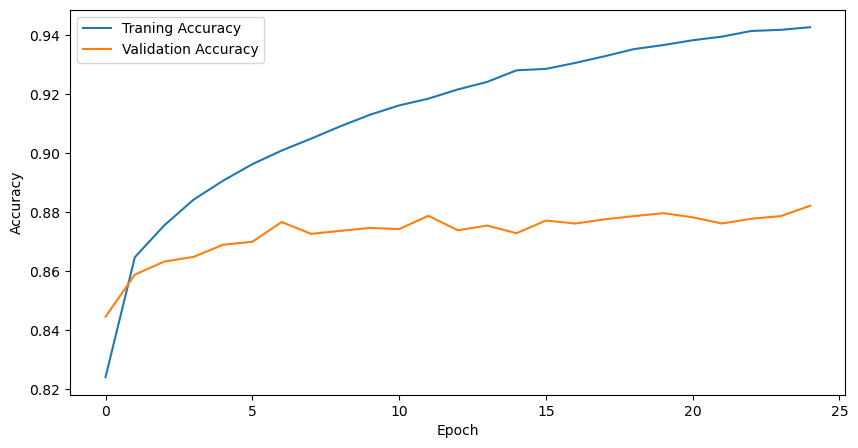

In [75]:
# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [76]:
if enabled_learning_rate_callback:
    lrs = 1e-4 * (10 ** (tf.range(epoch) / 12))
    plt.figure(figsize=(10, 7))
    plt.semilogx(lrs, history.history["loss"]) # used for creating line plots where the x-axis is scaled logarithmically (base-10 by default), while the y-axis remains linear (arithmetic scale)
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.title("Learning Rate vs Loss")